=== Advanced Model Evaluation (Random Forest) ===
New R-squared Score: 0.5703 (Hopefully much closer to 1.0!)
New Mean Absolute Error: ₹110.58


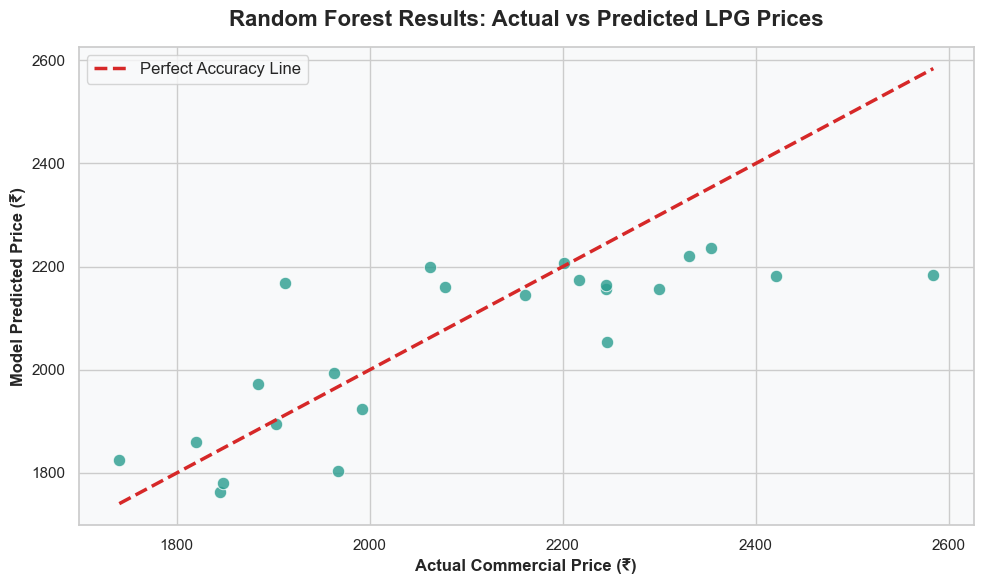

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load the main dataset
df = pd.read_csv("master_lpg_analysis_dataset_final.csv")

# 2. Select Features (X) and Target (y)
features = ['Distance_to_Port_km', 'Avg_Brent_Crude_USD']
target = 'Commercial Price'

# Drop any rows that might have missing data in these specific columns
model_df = df.dropna(subset=features + [target])

X = model_df[features]
y = model_df[target]

# 3. Train-Test Split
# We train the model on 80% of the data and test it on the unseen 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Make New Predictions
y_pred_rf = rf_model.predict(X_test)

# 3. Evaluate the New Model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Advanced Model Evaluation (Random Forest)")
print(f"New R-squared Score: {r2_rf:.4f}")
print(f"New Mean Absolute Error: ₹{mae_rf:.2f}")

# 4. Create the Upgraded "Actual vs Predicted" Plot
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#f8f9fa"})
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the new predictions in a premium forest green
sns.scatterplot(x=y_test, y=y_pred_rf, color="#2a9d8f", s=80, alpha=0.8, ax=ax)

# Draw the perfect prediction line
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
ax.plot([min_val, max_val], [min_val, max_val], color="#d62828", linestyle="--", linewidth=2.5, label="Perfect Accuracy Line")

ax.set_title("Random Forest Results: Actual vs Predicted LPG Prices", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Actual Commercial Price (₹)", fontsize=12, fontweight='bold')
ax.set_ylabel("Model Predicted Price (₹)", fontsize=12, fontweight='bold')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("random_forest_predictions.png", dpi=300)
plt.show()

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Page Config
st.set_page_config(page_title="LPG Price Analyst", layout="wide")
st.markdown("""
    <style>
    .main { background-color: #0e1117; }
    div[data-testid="stMetric"] {
        background-color: #161b22;
        border: 1px solid #30363d;
        border-radius: 10px;
        padding: 15px;
    }
    .report-card {
        background-color: #161b22;
        padding: 20px;
        border-radius: 10px;
        border-left: 5px solid #00d4ff;
    }
    </style>
    """, unsafe_allow_html=True)

# Data & Model Core 
@st.cache_resource
def train_model():
    # Loading dataset
    df = pd.read_csv("master_lpg_analysis_dataset_final.csv")
    features = ['Distance_to_Port_km', 'Avg_Brent_Crude_USD']
    target = 'Commercial Price'
    
    data = df.dropna(subset=features + [target])
    X, y = data[features], data[target]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    
    # Getting stats for the UI
    stats = {
        "avg_price": y.mean(),
        "max_dist": int(X['Distance_to_Port_km'].max()),
        "cv_score": cross_val_score(model, X, y, cv=5).mean(),
        "count": len(X)
    }
    return model, stats, X, y

model, stats, X_train, y_train = train_model()

# Header
st.title("LPG Supply Chain Analyst")
st.markdown(f"**Dataset size:** {stats['count']} records | **Model Accuracy:** {stats['cv_score']:.1%}")
st.divider()

# Sidebar Controls 
simulate_shock = st.sidebar.toggle("Simulate Market Shock")

if simulate_shock:
    crude_input = 140.0
    dist_input = stats['max_dist']
    st.sidebar.warning("Shock Mode Active: High Prices & Logistical Delays")
else:
    crude_input = st.sidebar.slider("Brent Crude Price ($/bbl)", 40.0, 160.0, 85.0)
    dist_input = st.sidebar.slider("Delivery Distance (km)", 0, stats['max_dist'], 300)

# Prediction Logic
input_df = pd.DataFrame([[dist_input, crude_input]], columns=X_train.columns)
prediction = model.predict(input_df)[0]
price_diff = prediction - stats['avg_price']

# Determine Risk Status
if prediction > 2200:
    status, color = "Critical", "#ff4b4b"
elif prediction > 1900:
    status, color = "Elevated", "#ffa500"
else:
    status, color = "Stable", "#00f040"

# Top Row: Metrics
m1, m2, m3, m4 = st.columns(4)
m1.metric("Predicted Price", f"₹{prediction:,.2f}", f"{price_diff:+,.2f}")
m2.metric("Crude Price", f"${crude_input}", f"{crude_input-85:+.1f}")
m3.metric("Distance", f"{dist_input} km")
m4.metric("Market Status", status)

st.write("") # Spacer

# Main Dashboard
tab_charts, tab_report = st.tabs(["Data Visualizations", "Executive Summary"])

with tab_charts:
    col_a, col_b = st.columns(2)
    
    with col_a:
        # Crude vs Price Sensitivity
        crude_range = np.linspace(40, 160, 50)
        temp_df = pd.DataFrame({
            'Distance_to_Port_km': [dist_input] * 50,
            'Avg_Brent_Crude_USD': crude_range
        })
        preds = model.predict(temp_df)
        
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=crude_range, y=preds, line=dict(color='#00d4ff', width=3), fill='tozeroy'))
        fig.update_layout(title="Price Sensitivity: Crude Oil", template="plotly_dark", height=350)
        st.plotly_chart(fig, use_container_width=True)

    with col_b:
        # Heatmap
        c_vals = np.linspace(50, 150, 20)
        d_vals = np.linspace(0, stats['max_dist'], 20)
        z_vals = [[model.predict(pd.DataFrame([[d, c]], columns=X_train.columns))[0] for c in c_vals] for d in d_vals]
        
        fig_heat = go.Figure(data=go.Heatmap(z=z_vals, x=c_vals, y=d_vals, colorscale='Viridis'))
        fig_heat.update_layout(title="Risk Heatmap (Crude vs Distance)", template="plotly_dark", height=350)
        st.plotly_chart(fig_heat, use_container_width=True)

with tab_report:
    st.markdown(f"""
    <div class="report-card">
        <h3>Analysis for {status} Market Conditions</h3>
        <p>The model predicts a commercial price of <b>₹{prediction:,.2f}</b>.</p>
    </div>
    """, unsafe_allow_html=True)
    
    st.write("")
    if status == "Critical":
        st.error("**Urgent:** Supply costs are reaching unsustainable levels. Inland logistics are heavily impacted by current crude volatility.")
    elif status == "Elevated":
        st.warning("**Note:** Moderate price pressure detected. Logistics premiums are rising due to distance variables.")
    else:
        st.success("**Operational:** Market conditions remain within standard deviations. No immediate intervention required.")
st.markdown("---")

Overwriting app.py
